# H3 Cell Rasterize + Band Stacking Demo

**A complete polygon → H3 polyfill → per-band rasterize → multi-band stack pipeline,
demonstrated on DEM elevation isobands.**

## What this notebook shows

This notebook demonstrates the full H3-cell rasterization workflow on a real-world
San Francisco Bay Area DEM — terrain that ranges from sea level at the Bay and
Pacific coast, up through Twin Peaks (\~280 m) and the SF Peninsula hills, across
the water to Mt Tamalpais (\~784 m) in Marin County. That \~800 m spread produces
eight meaningful 100 m elevation bands.

1. **Load a DEM** — SRTM tile covering the San Francisco Bay Area (`srtm_n37w123.tif`, EPSG:4326).
2. **Quantize into elevation isobands** — every 100 m produces a filled polygon ring.
   Each ring becomes a *band level* (analogous to a signal-strength threshold in a
   wireless-coverage pipeline).
3. **H3 polyfill** — convert each band polygon to the set of H3 cells at resolution 8
   whose centers fall inside the polygon.
4. **Shared grid spec** — `rx.rst_h3_gridspec` snaps a single aligned canvas over all
   bands combined, so the rasterized tiles are pixel-aligned and can be stacked.
5. **Per-band rasterize** — `rx.rst_h3_rasterize_agg` burns each band's H3 cells onto
   the shared canvas, producing one coverage tile per elevation band.
6. **Stack** — `rx.rst_frombands_agg` assembles the per-band tiles into a single
   multi-band GeoTIFF; `plot_raster` visualizes the stack as a false-colour composite.

## Telco / coverage-analysis analogy

San Francisco is a particularly apt stand-in for a wireless-coverage scenario: it is a
dense, hilly coastal city where terrain directly shadows RF propagation. The ridgeline
from Twin Peaks through the Marin hills creates hard coverage shadows for base stations
sited at lower elevations — exactly the kind of terrain where elevation isobands stand
in well for signal-strength coverage contours.

Replace *elevation band* with *signal-strength contour* and you have a
transmitter-coverage pipeline:

| DEM demo | Coverage-analysis equivalent |
|---|---|
| Elevation isoband polygon | Signal contour polygon (e.g. -80 dBm zone) |
| `band_level` (integer) | Threshold index (e.g. tier 1 / tier 2 / …) |
| H3 polyfill at res 8 | H3 coverage cells per threshold |
| Multi-band stacked tile | Multi-threshold stacked coverage raster |

## Runtime requirement

Run on a Databricks cluster or Serverless compute. The SRTM DEM tile is fetched by the
staging cell below (public AWS Terrain Tiles → the sample-data Unity Catalog Volume,
once, idempotent); outputs are empty until executed on a cluster. See `README.md` for
setup instructions.

---
_Last Modified: June 24, 2026_

![H3 Rasterize — DEM isobands to a multi-band H3 raster stack](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/h3-rasterize/h3-rasterize.png)

## Install GeoBrix

The lightweight `[light,viz]` extras are sufficient — no JAR or GDAL init script
required (when using the lightweight tier). The notebook can run on Serverless compute.

In [0]:
# Install GeoBrix with lightweight raster + visualization extras.
# Replace the file:// path with your staged wheel location
%pip install --quiet --disable-pip-version-check --force-reinstall --no-deps "geobrix @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.4.0-py3-none-any.whl"
%pip install --quiet "geobrix[light,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.4.0-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

## Imports and registration

In [0]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import rasterio
from rasterio.features import shapes as rio_shapes
from pyspark.sql import functions as F

import h3

# GeoBrix lightweight tier — runs on Serverless.
from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.vizx import plot_raster, plot_file, plot_static, cells_as_gdf, grid_as_gdf

# Register pyrx SQL UDFs and H3 UDTFs (rst_h3_rastertogridavg, etc.).
rx.register(spark)
register(spark)

In [ ]:
INTERACTIVE_PLOTS = False  # set True for interactive MapLibre maps

## DEM path and parameters

The SRTM tile `srtm_n37w123.tif` covers the San Francisco Bay Area (N37, W123) —
including the SF Peninsula, Marin headlands (Mt Tamalpais, ~784 m), and East Bay hills.
The tile is fetched by the staging cell below: on first run it downloads the public
AWS Terrain Tiles dataset, converts to GeoTIFF, and writes the result to the
sample-data Volume (idempotent — skipped if the file already exists).

In [0]:
# --- paths ---------------------------------------------------------------
DEM_PATH = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation/srtm_n37w123.tif"

# --- parameters -----------------------------------------------------------
H3_RESOLUTION = 8          # resolution 8 hexagons (~0.74 km² each)
BAND_STEP_M   = 100        # elevation isoband interval in metres
MIN_ELEV_M    = 0          # lower bound for isobands (sea-level baseline)
MAX_ELEV_M    = 800        # upper bound; SF Bay Area peaks at ~986 m (Mt Tamalpais area)

print(f"DEM : {DEM_PATH}")
print(f"H3 resolution : {H3_RESOLUTION}")
print(f"Band step : {BAND_STEP_M} m  (bands from {MIN_ELEV_M} to {MAX_ELEV_M} m)")

# --- pixel size (for ~3 px per hex edge at SF latitude) -----------------
import math
_edge_m = h3.average_hexagon_edge_length(H3_RESOLUTION, unit="m")
PIXEL_SIZE_DEG = (_edge_m / 3.0) / (111320.0 * math.cos(math.radians(37.8)))

print(f"Pixel size  : {PIXEL_SIZE_DEG:.7f} deg (~{_edge_m/3.0:.1f} m per pixel)")

DEM : /Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation/srtm_n37w123.tif
H3 resolution : 8
Band step : 100 m  (bands from 0 to 800 m)
Pixel size  : 0.0020138 deg (~177.1 m per pixel)


### Stage the sample DEM

The demo reads a 1°×1° SRTM tile (`srtm_n37w123.tif`, San Francisco Bay Area). This cell downloads it from the public AWS Terrain Tiles dataset and writes it to the Volume **once** — idempotent, and safe on Serverless (uses rasterio's bundled GDAL, no `gdal_translate` CLI). Download + conversion happen in node-local temp; the final file is copied to the Volume sequentially (FUSE-safe).

In [0]:
# Ensure the sample DEM is staged on the Volume (idempotent; Serverless- and classic-safe).
import os, shutil

if not os.path.exists(DEM_PATH):
    from databricks.labs.gbx.sample import get_temp_dir            # shipped in the geobrix wheel
    from databricks.labs.gbx.sample._bundle import download_srtm_to_path

    tmp = get_temp_dir()                                           # node-local scratch (NOT the Volume)
    tile = "N37W123"                                               # 1x1 deg SRTM tile; SW corner 37N, 123W
    hgt = download_srtm_to_path(tile, tmp / f"{tile}.hgt", f"SRTM {tile}")   # public AWS Terrain Tiles S3

    import rasterio                                                # bundled GDAL reads .hgt; no gdal CLI needed
    local_tif = tmp / "srtm_n37w123.tif"
    with rasterio.open(str(hgt)) as src:
        profile = {**src.profile, "driver": "GTiff"}
        with rasterio.open(str(local_tif), "w", **profile) as dst:
            dst.write(src.read())

    os.makedirs(os.path.dirname(DEM_PATH), exist_ok=True)          # Volume root must pre-exist; subdirs OK
    shutil.copy(str(local_tif), DEM_PATH)                          # FUSE-safe sequential copy to the Volume
    print(f"staged {DEM_PATH}")
else:
    print(f"{DEM_PATH} already present")

/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation/srtm_n37w123.tif already present


## Step 1 — Load DEM and extract elevation isobands

**This step runs on the driver (single node).** Rasterio reads the single-tile DEM
locally, then we quantize the elevation array into bands of `BAND_STEP_M` metres and
use `rasterio.features.shapes` to extract boundary polygons for each band level as
GeoJSON-like dicts. For the SF Bay Area tile (sea level → ~784 m), this yields eight
100 m bands.

Each band polygon represents the area where the terrain exceeds that elevation
threshold — directly analogous to a signal-coverage contour polygon in an RF
propagation model.

The genuinely distributed Spark work begins in Step 3, when `rst_h3_gridspec`,
`rst_h3_rasterize_agg`, and `rst_frombands_agg` fan out across executors.

In [0]:
# Read DEM on the driver (rasterio, FUSE-mounted Volume path).
with rasterio.open(DEM_PATH) as src:
    dem_transform = src.transform
    dem_crs       = src.crs
    dem_nodata    = src.nodata
    elevation     = src.read(1, masked=True).astype("float32")

print(f"DEM shape    : {elevation.shape}")
print(f"CRS          : {dem_crs}")
print(f"Transform    : {dem_transform}")
print(f"Elev range   : {float(elevation.min()):.0f} – {float(elevation.max()):.0f} m")

# Build the list of isoband thresholds.
thresholds = list(range(
    int(MIN_ELEV_M),
    int(min(MAX_ELEV_M, float(elevation.max()))),
    BAND_STEP_M,
))
print(f"Thresholds   : {thresholds} m ({len(thresholds)} bands)")

# For each threshold level, extract a binary mask (elevation > threshold) and
# run rasterio.features.shapes to get polygons in the DEM's CRS (EPSG:4326).
isoband_rows = []  # (band_level, geojson_geometry)

for level in thresholds:
    mask = (~elevation.mask) & (elevation.data > level)
    mask_uint8 = mask.astype("uint8")
    for geom, val in rio_shapes(mask_uint8, mask=mask_uint8, transform=dem_transform):
        if val == 1:
            isoband_rows.append({"band_level": level, "geometry": geom})

print(f"Total polygon shapes : {len(isoband_rows)}")

DEM shape    : (3601, 3601)
CRS          : EPSG:4326
Transform    : | 0.00, 0.00,-123.00|
| 0.00,-0.00, 38.00|
| 0.00, 0.00, 1.00|
Elev range   : -1967 – 986 m
Thresholds   : [0, 100, 200, 300, 400, 500, 600, 700] m (8 bands)
Total polygon shapes : 2381


### Render the DEM

The source elevation tile via `gbx.viz.plot_file` (auto-decimation + per-band 2–98% percentile stretch; single-band → viridis).

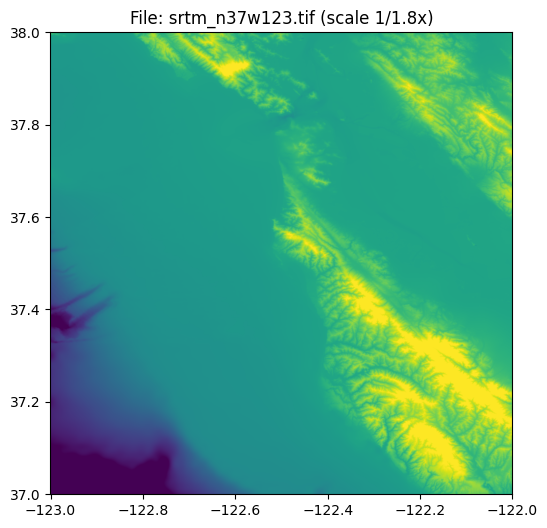

In [0]:
# Render the source DEM straight from the Volume path.
plot_file(DEM_PATH, fig_w=8, fig_h=6)

## Step 2 — H3 polyfill: polygons → H3 cells

**This step also runs on the driver (single node).** For each isoband polygon we call
`h3.polygon_to_cells` to fill it with H3 hexagonal cells at `H3_RESOLUTION`. We store
cell IDs as **64-bit integers** (via `h3.str_to_int`) because PySpark's `LongType`
maps to Scala `Long`.

This driver-side path is appropriate for a demo with a single DEM tile. In a production
pipeline ingesting many tiles you would distribute the polyfill: load DEM tiles into a
Spark DataFrame via `spark.read.format("binaryFile")` or the `gtiff_gbx` raster reader
(one row per tile), then call `h3.polygon_to_cells` inside a pandas UDF or UDTF so
isoband extraction and polyfill fan out across executors — one tile per task — before
the downstream Spark aggregations.

In [0]:
from pyspark.sql.types import LongType, IntegerType, StructType, StructField

cell_rows = []  # (band_level: int, cellid: int)

for row in isoband_rows:
    geom = row["geometry"]
    level = row["band_level"]

    coords = geom["coordinates"]
    if geom["type"] == "Polygon":
        rings = coords
    elif geom["type"] == "MultiPolygon":
        rings = coords[0]  # use the largest ring for demo brevity
    else:
        continue

    # rasterio shapes returns (lon, lat) tuples; h3.LatLngPoly expects (lat, lon).
    outer = [(lat, lon) for lon, lat in rings[0]]
    holes = [[(lat, lon) for lon, lat in ring] for ring in rings[1:]]

    try:
        poly = h3.LatLngPoly(outer, *holes)
        cells = h3.polygon_to_cells(poly, H3_RESOLUTION)
    except Exception:
        continue

    for c in cells:
        cell_rows.append((level, h3.str_to_int(c)))

print(f"Total (band_level, cellid) rows : {len(cell_rows)}")
# Deduplicate: a cell may be covered by multiple ring polygons for the same band.
cell_rows = list(set(cell_rows))
print(f"After dedup : {len(cell_rows)}")

# Create a Spark DataFrame with explicit schema.
schema = StructType([
    StructField("band_level", IntegerType(), False),
    StructField("cellid",     LongType(),    False),
])
cells_df = spark.createDataFrame(cell_rows, schema=schema)
cells_df.groupBy("band_level").count().orderBy("band_level").show()

Total (band_level, cellid) rows : 12179
After dedup : 12179
+----------+-----+
|band_level|count|
+----------+-----+
|         0| 5060|
|       100| 2937|
|       200| 1877|
|       300| 1091|
|       400|  635|
|       500|  343|
|       600|  173|
|       700|   63|
+----------+-----+



### Render the H3 polyfill

`plot_static` draws the polyfilled cells straight from the Spark DataFrame: with
`grid_system="h3"` it turns each `cellid` into its hexagon boundary and colours it by
elevation band, over a basemap (also can plot geoms). Each cell keeps its own geometry, so this per-cell view
is handy for inspecting individual hexagons at this data size. It renders as a static
image (so it shows on GitHub and the docs site); for an interactive pan/zoom map, pass the
same Spark DataFrame to `vizx.plot_interactive(cells_df, grid_system="h3", column="band_level")`
— it handles scale (falling back to a raster overlay for very large cell sets) and renders
inline in Databricks.

__Note:__ for much larger cell sets, dissolve first —
`cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"], dissolve_by="band_level")`
merges each band into a single footprint polygon (far fewer geometries to render), then
pass that GeoDataFrame to `plot_static`. (`plot_static` itself renders one hexagon per
cell; dissolving lives on the `cells_as_gdf` adapter.)

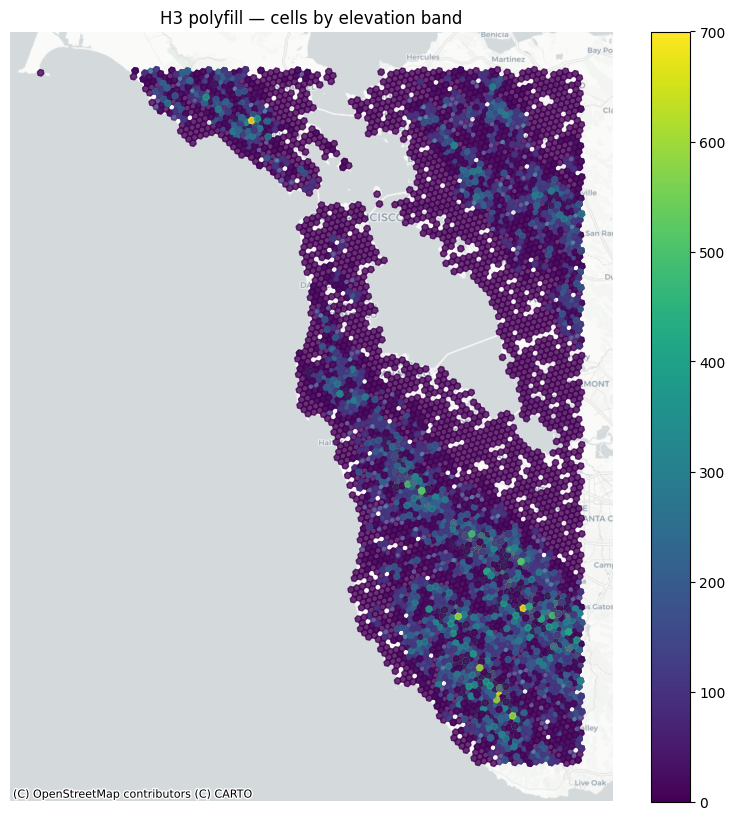

In [0]:
ax = plot_static(
      cells_df,
      geom_col="cellid",
      grid_system="h3",
      column="band_level",
      cmap="viridis",
      title="H3 polyfill — cells by elevation band",
  )

## Step 3 — Shared grid spec via `rst_h3_gridspec`

`rx.rst_h3_gridspec` computes a pixel-snapped bounding box and pixel dimensions
that span **all** H3 cells across **all** band levels. Because we pass no
grouping column here (we want a single shared canvas), it returns a single-row
DataFrame with a `grid` struct.

Using the same `grid` for every band ensures all per-band tiles are spatially
aligned — a prerequisite for `rst_frombands_agg` to produce a coherent stack.

In [0]:
# Compute the shared canvas over ALL cells (no grouping column → one grid row).
grid_df = rx.rst_h3_gridspec(cells_df, "cellid", pixel_size=PIXEL_SIZE_DEG)
grid_row = grid_df.first()
g = grid_row["grid"]

print("Shared canvas grid spec:")
print(f"  xmin={g['xmin']:.6f}  ymin={g['ymin']:.6f}")
print(f"  xmax={g['xmax']:.6f}  ymax={g['ymax']:.6f}")
print(f"  pixel_size={g['pixel_size']:.6f}")
print(f"  width={g['width']}  height={g['height']}  srid={g['srid']}")

# Broadcast the grid constants to all rows so rst_h3_rasterize_agg
# receives the same extent per group.
cells_with_grid = cells_df.withColumn("xmin",   F.lit(g["xmin"]))\
                           .withColumn("ymin",   F.lit(g["ymin"]))\
                           .withColumn("xmax",   F.lit(g["xmax"]))\
                           .withColumn("ymax",   F.lit(g["ymax"]))\
                           .withColumn("width",  F.lit(g["width"]))\
                           .withColumn("height", F.lit(g["height"]))

Shared canvas grid spec:
  xmin=-122.993628  ymin=36.992336
  xmax=-121.988719  ymax=38.009329
  pixel_size=0.002014
  width=499  height=505  srid=4326


### Render the shared canvas over the cells
  
`rst_h3_gridspec` returns the shared raster canvas — the bounding rectangle (and
pixel grid) every per-band raster aligns to. Drawing that rectangle over the cells
shows the extent the H3 cells get binned into: we render the cells with
`plot_static`, then overlay the canvas outline on the same axes.

`plot_static` reprojects layers to Web Mercator (EPSG:3857) so they line up with
the basemap, so the boundary overlay is reprojected to match before drawing.

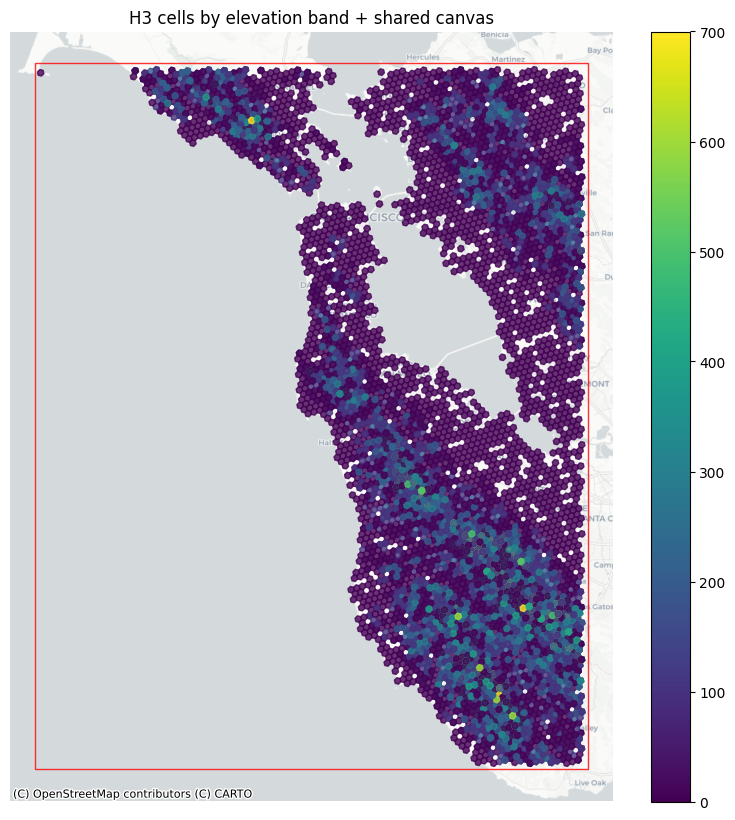

In [0]:
# Multi-layer (static): per-band H3 cell footprints + the shared-canvas rectangle on
# one matplotlib axes, over a basemap. Static so it renders on GitHub + the docs (see
# the note above); for an interactive pan/zoom map, build GeoDataFrames with
# cells_as_gdf(...) / grid_as_gdf(...) and pass to plot_interactive([vector_layer(...)]).
from databricks.labs.gbx.vizx import plot_static, grid_as_gdf
grid_gdf = grid_as_gdf(g)  # g = grid_row["grid"] -> the shared canvas spec

# Cells coloured by elevation band (straight from the Spark DataFrame) over a basemap,
# then the shared canvas as a red OUTLINE (fill=False so it doesn't cover the cells;
# basemap=False so it doesn't re-fetch tiles). Both layers reproject to 3857 and align.
ax = plot_static(
    cells_df,
    grid_system="h3",
    column="band_level",
    cmap="viridis",
    title="H3 cells by elevation band + shared canvas",
)
ax = plot_static(grid_gdf, ax=ax, fill=False, edgecolor="red", basemap=False)

## Step 4 — Per-band rasterize with `rst_h3_rasterize_agg`

`rst_h3_rasterize_agg` burns a group's H3 cells onto the shared canvas,
producing a presence mask (1.0 where a cell's centroid falls, NoData elsewhere).
Supplying the explicit extent from `rst_h3_gridspec` guarantees every per-band
tile has identical pixel dimensions — which is required for stacking.

We group by `band_level` so each elevation threshold produces one tile.

Because the per-pixel rasterize is expensive and we read these tiles again in the
next two steps, we materialize them once into a **session-scoped [temporary table](https://docs.databricks.com/aws/en/tables/temporary-tables)**
(`CREATE TEMP TABLE`). On Serverless, `.cache()` / `.persist()` are unavailable, so a
temp table is the idiomatic way to avoid recomputing the burn; it is automatically
dropped when the session ends. Requires Serverless or DBR 18.1+ (not dedicated /
single-user clusters).

In [0]:
# One rasterized tile per band level, all on the shared canvas.
bands_df = cells_with_grid.groupBy("band_level").agg(
    rx.rst_h3_rasterize_agg(
        "cellid",
        xmin="xmin",
        ymin="ymin",
        xmax="xmax",
        ymax="ymax",
        width="width",
        height="height",
    ).alias("tile")
)

# Materialize the per-band tiles ONCE into a session-scoped TEMP TABLE. The
# per-pixel rasterize is expensive, and on Serverless .cache()/.persist() are
# unavailable -- a temporary table is the idiomatic way to materialize an
# intermediate so the next two steps read it back instead of recomputing the burn.
# It is auto-dropped when the session ends. Requires Serverless or DBR 18.1+
# (NOT supported on dedicated / single-user clusters). Temp tables are created via
# SQL DDL over a temp view -- the DataFrame writer API does not apply to them.
bands_df.createOrReplaceTempView("_bands_src")
spark.sql("CREATE OR REPLACE TEMP TABLE band_tiles AS SELECT * FROM _bands_src")
bands_df = spark.table("band_tiles").orderBy("band_level")

print(f"Band tiles: {bands_df.count()} rows")
bands_df.select("band_level",
                F.expr("gbx_rst_width(tile)  AS px_width"),
                F.expr("gbx_rst_height(tile) AS px_height"),
                F.expr("gbx_rst_numbands(tile) AS numbands")).show()

Band tiles: 8 rows
+----------+--------+---------+--------+
|band_level|px_width|px_height|numbands|
+----------+--------+---------+--------+
|         0|     499|      505|       1|
|       100|     499|      505|       1|
|       200|     499|      505|       1|
|       300|     499|      505|       1|
|       400|     499|      505|       1|
|       500|     499|      505|       1|
|       600|     499|      505|       1|
|       700|     499|      505|       1|
+----------+--------+---------+--------+



### Inspect band coverage shapes

Each per-band tile is a binary presence mask (1.0 where a cell centroid falls,
NoData elsewhere). We overlay two **mid-coverage** bands on a single plot — each a
distinct colour with a legend — so you can see directly how coverage shrinks toward
the hilltops as the elevation threshold rises. The lower (larger) band is drawn
first and the higher (smaller) band on top; both read cheaply from the `band_tiles`
temp table, and NoData is transparent over a light-grey background.

band_level = 200 m  (1877 cells)
band_level = 400 m  (635 cells)


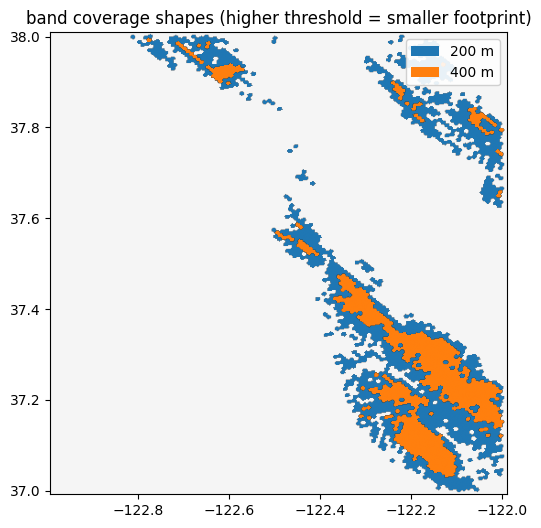

In [0]:
# Overlay two MID-coverage bands on one plot (each a distinct colour + legend) to
# show how coverage shrinks with elevation. The lowest band fills the canvas and the
# highest is a sparse speck, so pick bands between ~8% and ~45% of the densest. Both
# rows read from the band_tiles temp table -- no rasterization is recomputed here.
from databricks.labs.gbx.vizx import plot_mask_layers

counts = {r["band_level"]: r["count"]
          for r in cells_df.groupBy("band_level").count().collect()}
mx = max(counts.values())
sweet = [lvl for lvl in sorted(counts) if 0.08 * mx <= counts[lvl] <= 0.45 * mx]
if len(sweet) >= 2:
    show_levels = [sweet[0], sweet[-1]]          # lower (larger) first, higher on top
else:
    ordered = sorted(counts)
    show_levels = ordered[len(ordered) // 3: len(ordered) // 3 + 2] or ordered[:2]

layers = []
for lvl in show_levels:
    row = bands_df.filter(F.col("band_level") == lvl).first()
    print(f"band_level = {lvl} m  ({counts[lvl]} cells)")
    layers.append((f"{lvl} m", row["tile"]["raster"]))

plot_mask_layers(layers, fig_w=8, fig_h=6,
                 title="band coverage shapes (higher threshold = smaller footprint)")

## Step 5 — Stack bands with `rst_frombands_agg`

`rst_frombands_agg` assembles the per-band tiles into a single multi-band
GeoTIFF, ordered by `band_level` ascending. Band 1 in the stacked raster
corresponds to the lowest elevation threshold (densest coverage); the highest
band corresponds to the highest threshold (sparsest coverage).

In a wireless-coverage pipeline this multi-band tile would represent overlapping
coverage tiers — e.g. Band 1 = outdoor coverage, Band 2 = indoor marginal,
Band 3 = indoor reliable — ready for downstream analysis or PMTiles export.

In [0]:
# Add a sequential band_index starting at 1 so rst_frombands_agg orders correctly.
from pyspark.sql.window import Window

w = Window.orderBy("band_level")
indexed = bands_df.withColumn(
    "band_index",
    F.row_number().over(w).cast("int"),
)

# Stack all per-band tiles into one multi-band tile.
stacked_df = indexed.agg(
    rx.rst_frombands_agg("tile", "band_index").alias("stacked")
)

stacked_row = stacked_df.first()
stacked_tile = stacked_row["stacked"]
print("Stacked tile schema:", stacked_tile.asDict().keys())

# Quick metadata check via SQL accessors.
meta = stacked_df.selectExpr(
    "gbx_rst_numbands(stacked) AS n_bands",
    "gbx_rst_width(stacked)    AS width",
    "gbx_rst_height(stacked)   AS height",
    "gbx_rst_srid(stacked)     AS srid",
).first()
print(f"Bands: {meta['n_bands']}  Width: {meta['width']}  Height: {meta['height']}  SRID: {meta['srid']}")

Stacked tile schema: dict_keys(['cellid', 'raster', 'metadata'])
Bands: 8  Width: 499  Height: 505  SRID: 4326


### Visualize the stacked multi-band raster

`plot_raster` with `composite="depth"` renders **coverage depth**: the per-pixel
count of bands that cover each pixel (0 = uncovered, N = all N thresholds cover
that location).  The result is a bright viridis gradient — high-altitude terrain
covered by only the lowest bands appears at the low end; valley floors and
coastline covered by all eight thresholds appear at the high end.  Uncovered
pixels are masked transparent (the ocean and areas outside SF).

This is far more readable than an RGB-of-presence-masks composite, which is
dominated by black (NoData) and gives no sense of the underlying terrain.

In a wireless-coverage pipeline the same view shows overlapping coverage tiers:
bright pixels have indoor-reliable coverage; dim pixels have only outdoor coverage.

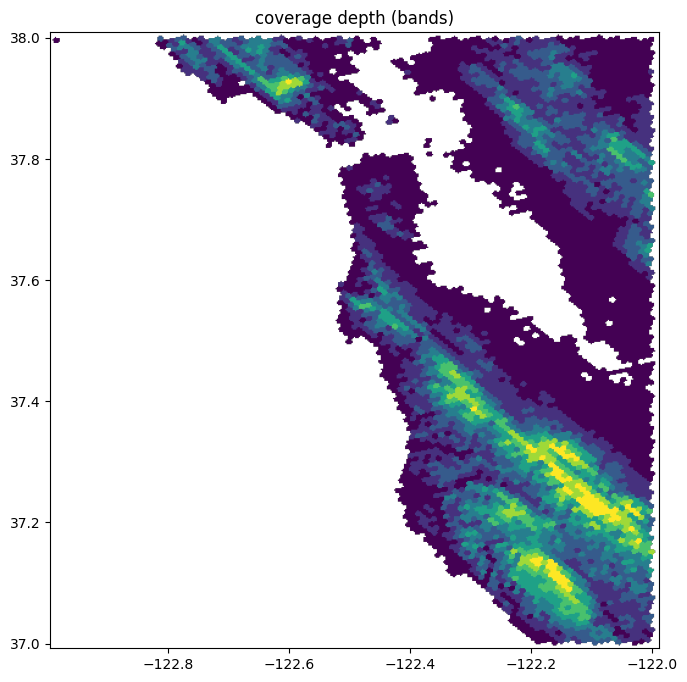

In [0]:
# Render the stacked raster as a coverage-depth map.
# composite="depth" counts, per pixel, how many bands cover it → viridis gradient.
# Uncovered pixels (NoData in all bands) are masked transparent.
plot_raster(stacked_tile["raster"], composite="depth", fig_w=10, fig_h=8)

Multi-layer view: the coverage-depth raster overlaid with H3 cell boundaries by elevation band — pan and zoom to explore the spatial distribution.

In [ ]:
if INTERACTIVE_PLOTS:
    from databricks.labs.gbx.vizx import raster_layer, grid_layer, plot_interactive
    plot_interactive([
        raster_layer(stacked_tile["raster"]),
        grid_layer(cells_df, grid_system="h3", cellid_col="cellid", column="band_level", opacity=0.25),
    ])

## Summary and next steps

This notebook demonstrated the full H3-cell rasterization pipeline on a San Francisco
Bay Area DEM, producing eight elevation bands (0–800 m, 100 m step) at H3 resolution 8:

| Step | Function | Output |
|---|---|---|
| DEM → isobands (driver) | `rasterio.features.shapes` | GeoJSON polygon per band |
| Polygon → H3 cells (driver) | `h3.polygon_to_cells` | `(band_level, cellid)` rows |
| Shared canvas (Spark) | `rx.rst_h3_gridspec` | `grid` struct (xmin…height) |
| H3 cells → tile (Spark) | `rx.rst_h3_rasterize_agg` | single-band tile per band |
| Stack bands (Spark) | `rx.rst_frombands_agg` | multi-band GeoTIFF tile |
| Inspect bands (viz) | `plot_mask_layers` | overlaid band footprints + legend |
| Visualize stack (viz) | `plot_raster(composite="depth")` | coverage-depth figure |

- **Scaling to many tiles**: in production, ingest multiple DEM tiles via
  `spark.read.format("binaryFile")` or the `gtiff_gbx` raster reader (one row per
  tile) and run isoband extraction plus H3 polyfill inside UDFs/UDTFs so the full
  prep pipeline — not just the rasterize/stack aggregations — fans out across
  executors.

### Adapting to a wireless-coverage pipeline

Replace the elevation DEM with contour polygons derived from RF propagation
model outputs. Each contour polygon represents signal strength above a threshold
(e.g. −80 dBm for outdoor, −95 dBm for indoor marginal). The rest of the
pipeline is identical — the stacked raster encodes multi-tier coverage that can
be exported as PMTiles for web visualization or joined against subscriber
location data for churn analysis.

### Further reading

- [GeoBrix RasterX API](https://databrickslabs.github.io/geobrix/docs/api/rasterx) — full function reference
- [EO-Series notebooks](../eo-series/) — STAC download, band stacking, clipping pipeline